In [61]:
#Importing necessary libraries 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

#setting plot style for clean outputs
sns.set_style("whitegrid")


In [63]:
#loading data 
df = pd.read_csv('Prodcut_Sales.csv')
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,CA-2016-152156,08/11/2016,11/11/2016,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,CA-2016-152156,08/11/2016,11/11/2016,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,CA-2016-138688,12/06/2016,16/06/2016,Second Class,DV-13045,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [65]:
#Printing the dataset information
print('--- Data Info ---')
print(df.info())

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order ID      9994 non-null   object 
 1   Order Date    9994 non-null   object 
 2   Ship Date     9994 non-null   object 
 3   Ship Mode     9994 non-null   object 
 4   Customer ID   9994 non-null   object 
 5   Segment       9994 non-null   object 
 6   Country       9994 non-null   object 
 7   City          9994 non-null   object 
 8   State         9994 non-null   object 
 9   Postal Code   9994 non-null   int64  
 10  Region        9994 non-null   object 
 11  Product ID    9994 non-null   object 
 12  Category      9994 non-null   object 
 13  Sub-Category  9994 non-null   object 
 14  Product Name  9994 non-null   object 
 15  Sales         9994 non-null   float64
 16  Quantity      9994 non-null   int64  
 17  Discount      9994 non-null   float64
 18  Profit    

**Data Cleaning and Pre-processing**


In [68]:
#Checking for missing values
print('--- Missing values ---')
print(df.isnull().sum())

--- Missing values ---
Order ID        0
Order Date      0
Ship Date       0
Ship Mode       0
Customer ID     0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Product ID      0
Category        0
Sub-Category    0
Product Name    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64


There are NO Missing Values in the dataset.

In [70]:
#Checking if there are any duplicate values, and removing them if any.
print('--- Duplicate rows ---')
print(df.duplicated().sum())

--- Duplicate rows ---
1


In [72]:
#We remove the duplicated row
df = df.drop_duplicates()
print(df.duplicated().sum())

0


In [74]:
# Correcting the data types for date time objects with the proper format
# Adding dayfirst=True to handle dates in day/month/year format
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9993 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order ID      9993 non-null   object        
 1   Order Date    9993 non-null   datetime64[ns]
 2   Ship Date     9993 non-null   datetime64[ns]
 3   Ship Mode     9993 non-null   object        
 4   Customer ID   9993 non-null   object        
 5   Segment       9993 non-null   object        
 6   Country       9993 non-null   object        
 7   City          9993 non-null   object        
 8   State         9993 non-null   object        
 9   Postal Code   9993 non-null   int64         
 10  Region        9993 non-null   object        
 11  Product ID    9993 non-null   object        
 12  Category      9993 non-null   object        
 13  Sub-Category  9993 non-null   object        
 14  Product Name  9993 non-null   object        
 15  Sales         9993 non-null   float64      

**Outlier Detection**

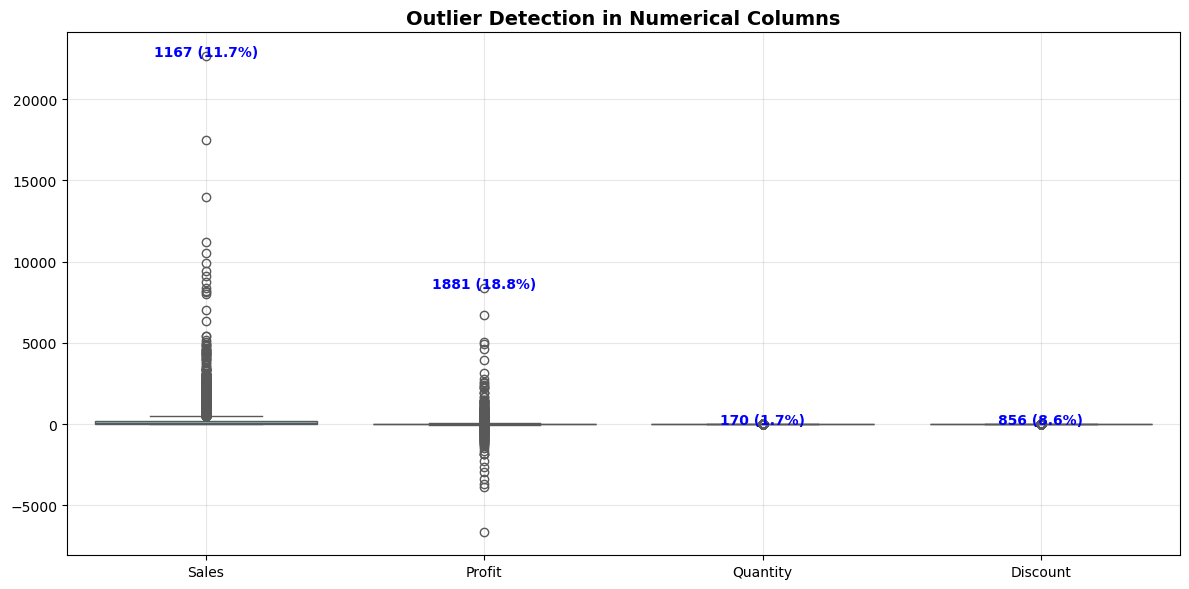

In [223]:
#Plotting outliers (extreme values) using boxplots
numerical_cols = ['Sales', 'Profit', 'Quantity', 'Discount']

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numerical_cols], color='skyblue')
plt.title('Outlier Detection in Numerical Columns', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

for i, col in enumerate(numerical_cols):
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    outliers = df[(df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)]
    outlier_count = len(outliers)
    percentage = outlier_count / len(df) * 100

    # Add text annotation above each box
    plt.text(i, df[col].max(), f'{outlier_count} ({percentage:.1f}%)', 
             horizontalalignment='center', color='blue', fontweight='bold')

plt.tight_layout()
plt.savefig('outlier.png', dpi=300)
plt.show()

Here, in a sales domain, these outliers are not necessarily errors. They could be right, high-value orders or high profit products and therefore removing them could cause critical business information loss. 

Instead of removing them, we will continue with the analysis keeping them in mind and understand the potential influence of these outliers on the profit.


**Exploratory Data Analysis (EDA)**

In [83]:
print('--- Descriptive statistics ---')
print(df.describe())

--- Descriptive statistics ---
                          Order Date                      Ship Date  \
count                           9993                           9993   
mean   2016-04-30 01:53:33.089162240  2016-05-04 00:53:19.039327488   
min              2014-01-03 00:00:00            2014-01-07 00:00:00   
25%              2015-05-23 00:00:00            2015-05-27 00:00:00   
50%              2016-06-26 00:00:00            2016-06-29 00:00:00   
75%              2017-05-14 00:00:00            2017-05-18 00:00:00   
max              2017-12-30 00:00:00            2018-01-05 00:00:00   
std                              NaN                            NaN   

        Postal Code         Sales     Quantity     Discount       Profit  
count   9993.000000   9993.000000  9993.000000  9993.000000  9993.000000  
mean   55191.576403    229.852846     3.789753     0.156188    28.660971  
min     1040.000000      0.444000     1.000000     0.000000 -6599.978000  
25%    23223.000000     17.28

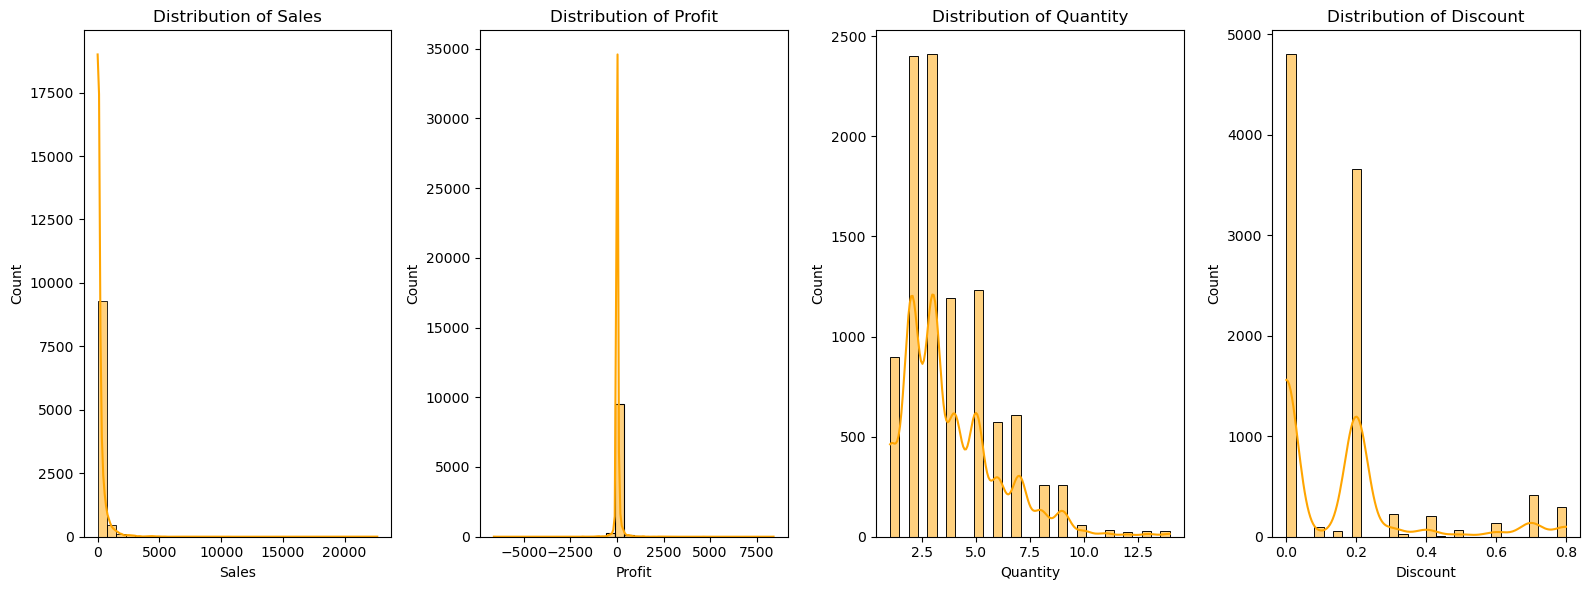

In [184]:
#Components Distribution Analysis
plt.figure(figsize=(16, 6))
for i, col in enumerate(['Sales', 'Profit', 'Quantity', 'Discount']):
    plt.subplot(1, 4, i+1)
    sns.histplot(df[col], kde=True, color='orange', bins=30)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.savefig('numeric_distribution.png', dpi=300)
plt.show()

1. The sales distribution analysis reveals a highly right-skewed pattern, with most transactions concentrated below $2,500 and a long tail of occasional high-value sales. This suggests the business model centers on smaller, frequent purchases, punctuated by the occasional large transaction that stretches the distribution.

2. The profit distribution, while more balanced, still exhibits positive skewness and ranges from approximately –6599.97 to 8399.97 as visible in the descriptive statistics. The bulk of transactions generate modest positive returns between 0 and 500, but the presence of negative profits points to loss-making sales, likely driven by promotions, returns, or clearance activities.

3. The Quantity shows a normal distribution, maintaining a good ordering situation while Discounts shows a varied and different fluctuations throughout.

--- Frequency of categorical attributes ---


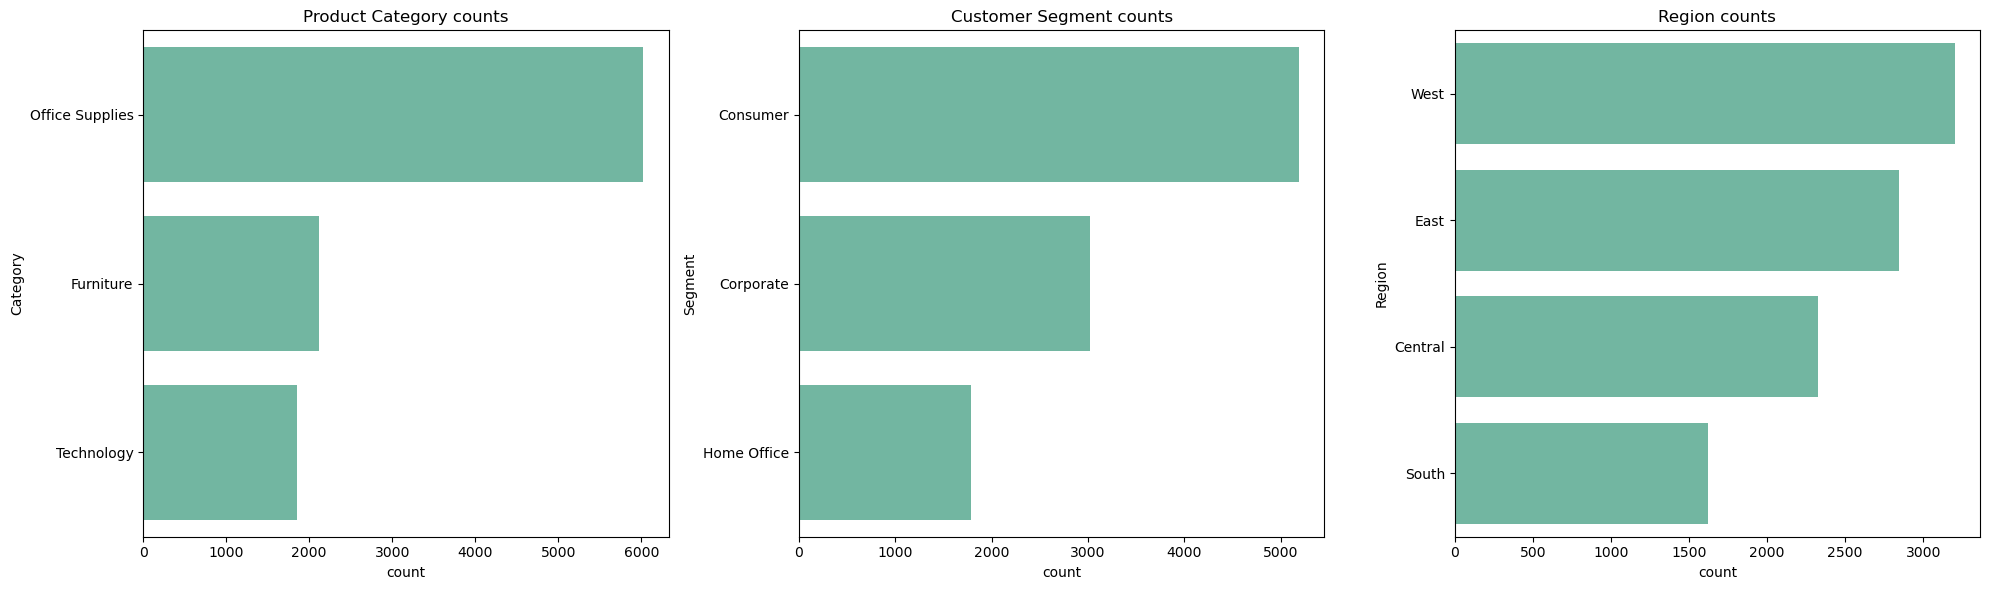

In [187]:
#Frequency of categorical attributes
#It will show the composition of the dataset

print('--- Frequency of categorical attributes ---')
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.countplot(y='Category', data=df, ax=axes[0], order=df['Category'].value_counts().index)
axes[0].set_title('Product Category counts')

sns.countplot(y='Segment', data=df, ax=axes[1], order=df['Segment'].value_counts().index)
axes[1].set_title('Customer Segment counts')

sns.countplot(y='Region', data=df, ax=axes[2], order=df['Region'].value_counts().index)
axes[2].set_title('Region counts')

plt.tight_layout()
plt.savefig('categorical_distribution.png', dpi=300)
plt.show()

This shows regional and segment-wise distributions depicting a high and big customer base in the West.

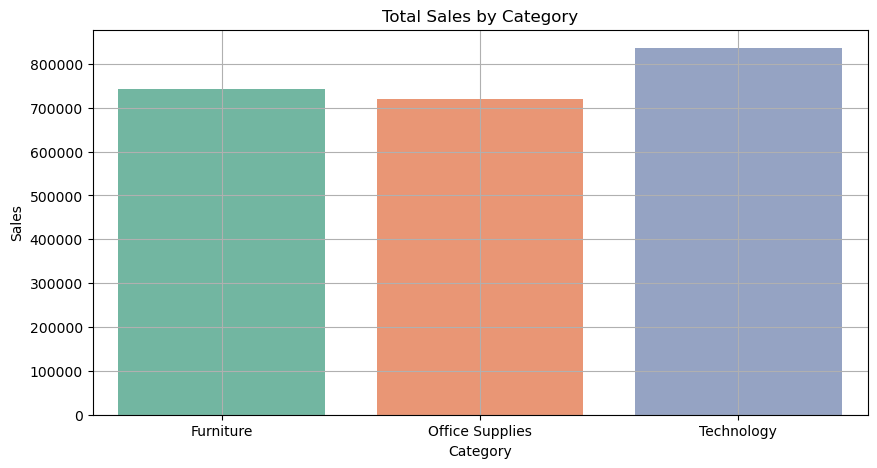

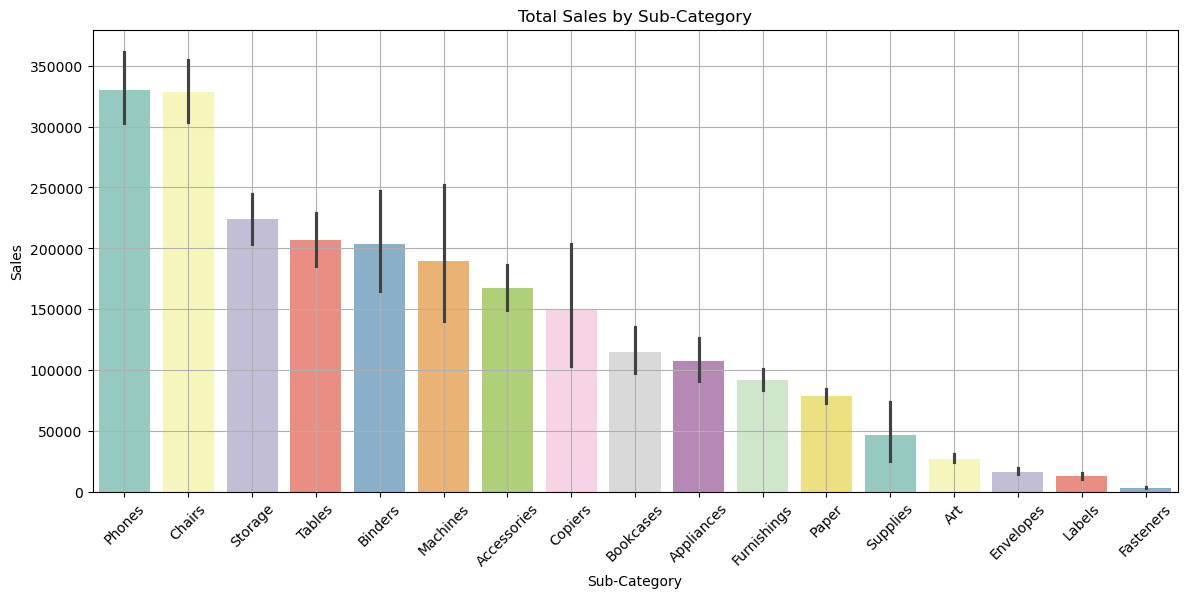

In [190]:
# Sales by category
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Category', y='Sales', estimator='sum', ci=None, palette='Set2')
plt.title("Total Sales by Category")
plt.grid(True)
plt.savefig('sales_category.png', dpi=300)
plt.show()

# Sales by sub-category
plt.figure(figsize=(14, 6))
order = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).index
sns.barplot(data=df, x='Sub-Category', y='Sales', estimator='sum', order=order, palette='Set3')
plt.title("Total Sales by Sub-Category")
plt.xticks(rotation=45)
plt.grid(True)
plt.savefig('sales_subcategory.png', dpi=300)
plt.show()

The above figures identifies Technology as the highest revenue generator, while from the previous figure, it is visible that Office supplies dominates volume.

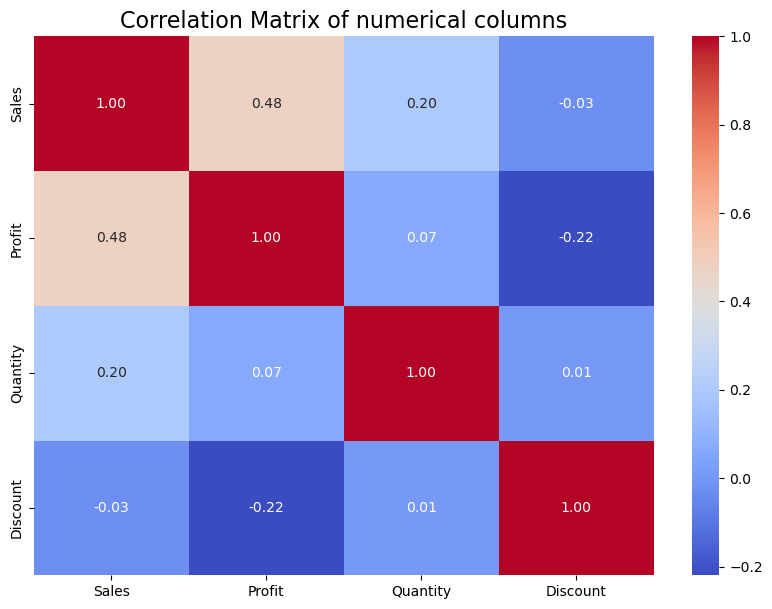

In [193]:
#lets find out how all the numerical values are correlated to one another
plt.figure(figsize=(10, 7))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of numerical columns', fontsize=16)
plt.savefig('correlation_matrix.png', dpi=300)
plt.show()

A key finding here is the relatioship between Discount and Profit which is negative (-0.22) and arises the need for accurate discount management

**RESEARCH QUESTIONS**

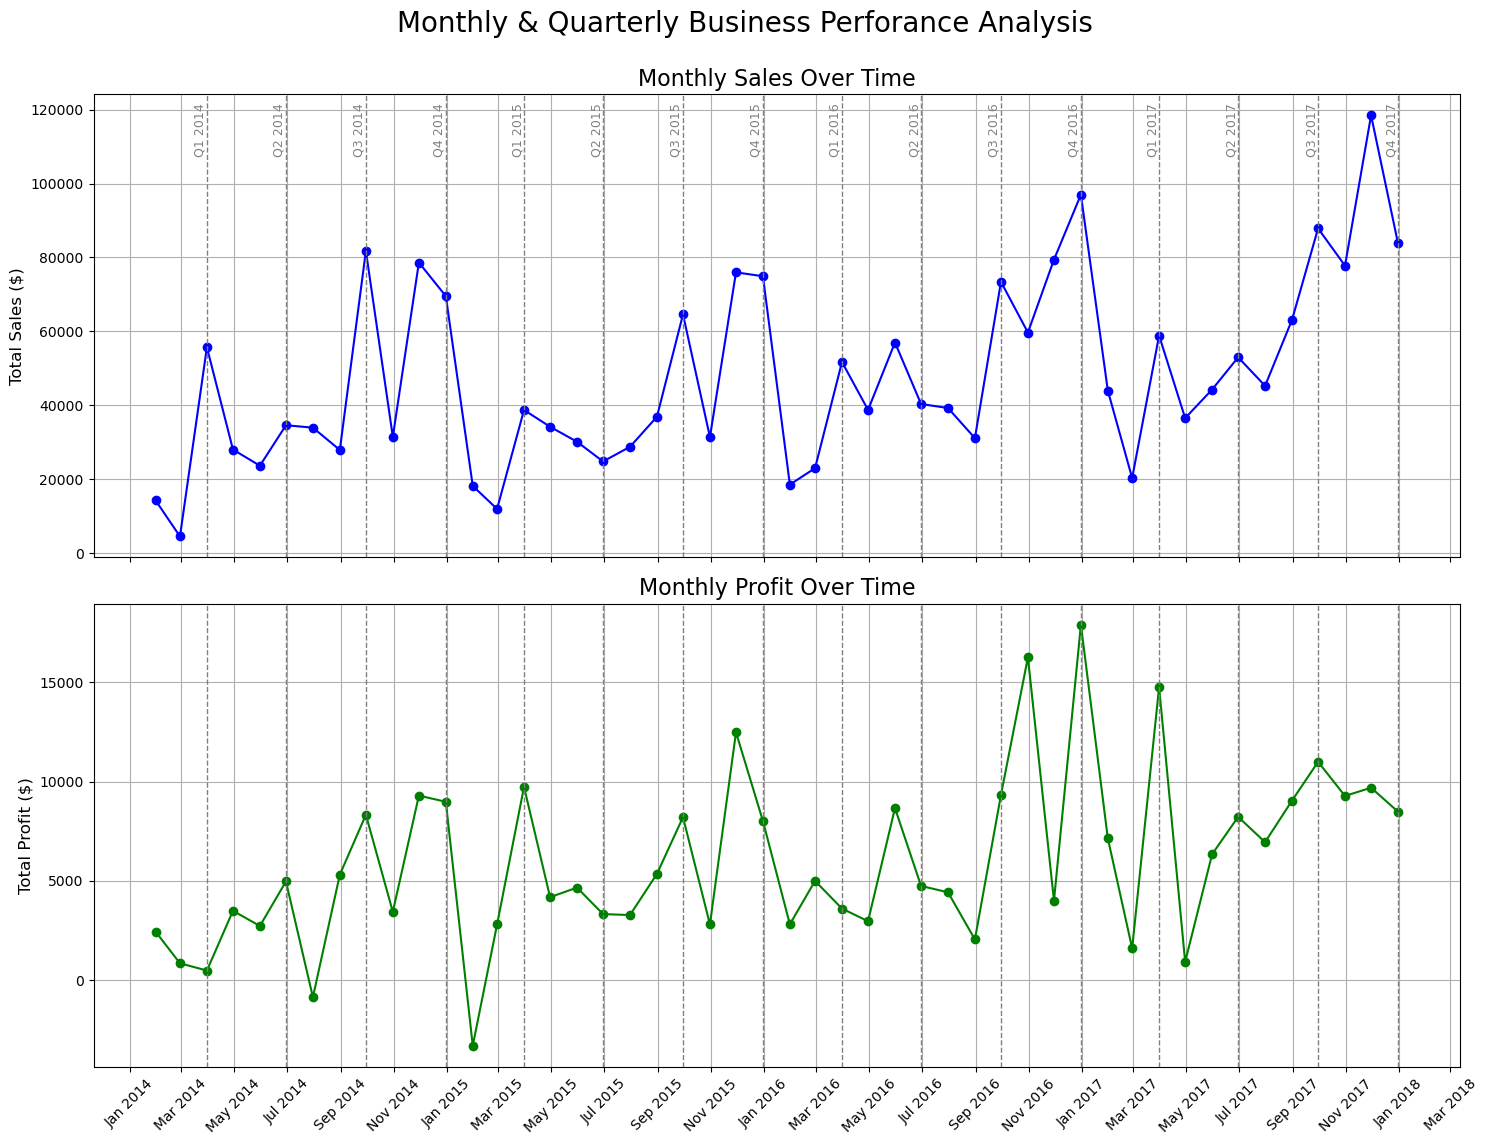

In [199]:
#RQ1: How can the company improve the inventory management, Marketing & campaign planning, overall business based on quarterly
# and monthly sales and profit patterns.

#----- Time Series Analysis -----
import matplotlib.dates as mdates

#setting order date as the index of the dataframe
df_time = df.set_index('Order Date')

#resampling the data by month
monthly_performance = df_time[['Sales', 'Profit']].resample('M').sum()
quarters = monthly_performance.resample('Q').sum().index
quarter_labels = [f"Q{q.quarter} {q.year}" for q in quarters]

fig, (ax1, ax2) = plt.subplots(2,1, figsize=(15,12), sharex=True)

#Monthly sales
ax1.plot(monthly_performance.index, monthly_performance['Sales'], marker='o', linestyle='-', color='b')
ax1.set_title('Monthly Sales Over Time', fontsize=16)
ax1.set_ylabel('Total Sales ($)', fontsize=12)
ax1.grid(True)

#Monthly Profit
ax2.plot(monthly_performance.index, monthly_performance['Profit'], marker='o', linestyle='-', color='g')
ax2.set_title('Monthly Profit Over Time', fontsize=16)
ax2.set_ylabel('Total Profit ($)', fontsize=12)
ax2.grid(True)

#Quarter lines
for i, quarter_start in enumerate(quarters):
    ax1.axvline(x=quarter_start, color='gray', linestyle='--', linewidth=1)
    ax2.axvline(x=quarter_start, color='gray', linestyle='--', linewidth=1)

    #labeling quarters in figure
    ax1.text(
        quarter_start,
        ax1.get_ylim()[1] * 0.98,
        quarter_labels[i],
        rotation=90,
        fontsize=9,
        color='gray',
        ha='right',
        va='top'
    )

ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
    
plt.suptitle('Monthly & Quarterly Business Perforance Analysis', fontsize=20, y=0.95)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('time_series.png', dpi=300)
plt.show()

This reveals that there is some kind of rise in both sales and profit in Q4, more specially in November, probably because of holidays. 

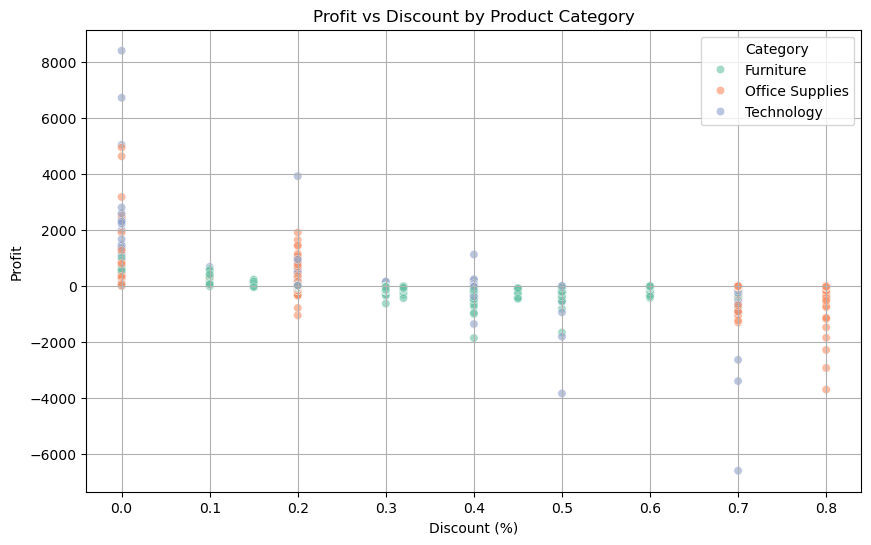

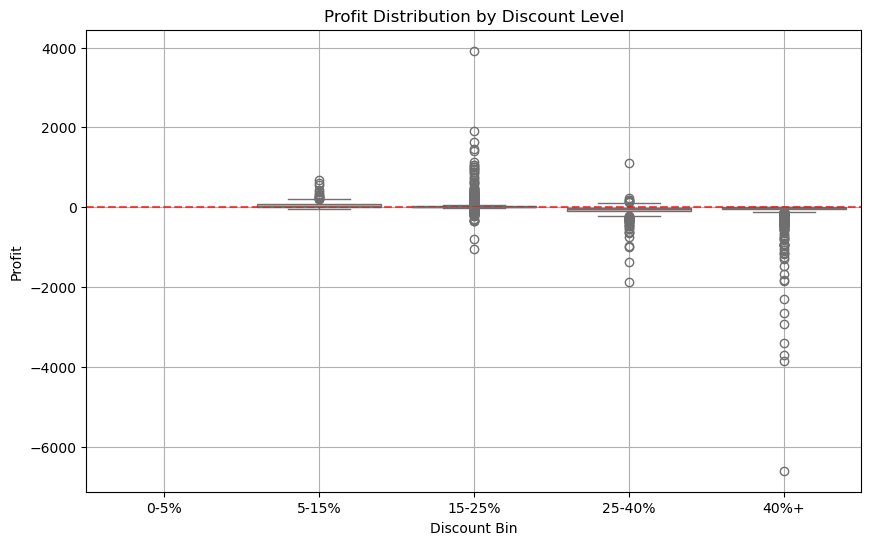

In [202]:
#RQ2: What is the relationship between discount levels and profitability, 
#and is there a threshold point where higher discounts lead to loss?

#step 1: Scatterplot of discount vs Profit
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.6)
plt.title("Profit vs Discount by Product Category")
plt.xlabel("Discount (%)")
plt.ylabel("Profit")
plt.grid(True)
plt.savefig('discount_profit_scatterplot.png', dpi=300)
plt.show()

#step 2: Boxplot of Profit per Discount bracket
# Create discount bins
df['Discount_Bin'] = pd.cut(df['Discount'], 
                           bins=[0, 0.05, 0.15, 0.25, 0.40, 1.0], 
                           labels=['0-5%', '5-15%', '15-25%', '25-40%', '40%+'])

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Discount_Bin', y='Profit', palette='pastel')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Break-even')
plt.title("Profit Distribution by Discount Level")
plt.xlabel("Discount Bin")
plt.ylabel("Profit")
plt.grid(True)
plt.savefig('boxplot.png', dpi=300)
plt.show()



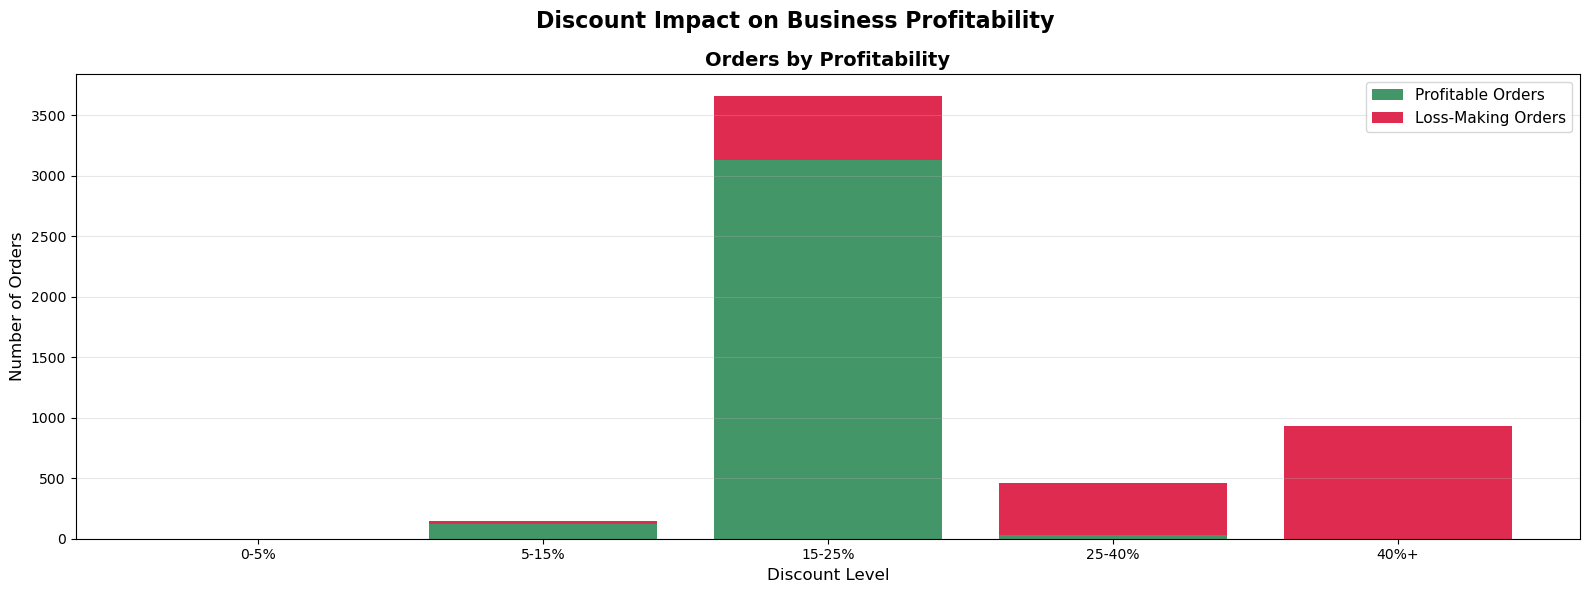

In [215]:
#adding one more visuaization to see clearly how discount and number of orders have impact on profit 
plt.style.use('default')
sns.set_palette("Set2")

# Creating discount bins
df['Discount_Bin'] = pd.cut(df['Discount'], 
                           bins=[0, 0.05, 0.15, 0.25, 0.40, 1.0], 
                           labels=['0-5%', '5-15%', '15-25%', '25-40%', '40%+'])

fig, ax1 = plt.subplots(1, 1, figsize=(16, 6))
fig.suptitle('Discount Impact on Business Profitability', fontsize=16, fontweight='bold')

# Calculatng profitable and unprofitable counts
stack_data = df.groupby('Discount_Bin').apply(
    lambda x: pd.Series({
        'Profitable': (x['Profit'] > 0).sum(),
        'Unprofitable': (x['Profit'] <= 0).sum(),
        'Total': len(x)
    })
).reset_index()

# Calculating success rates for labels
stack_data['Success_Rate'] = (stack_data['Profitable'] / stack_data['Total'] * 100).round(0)

# Creating stacked bars
profitable_bars = ax1.bar(stack_data['Discount_Bin'], stack_data['Profitable'], 
                         label='Profitable Orders', color='#2E8B57', alpha=0.9)
unprofitable_bars = ax1.bar(stack_data['Discount_Bin'], stack_data['Unprofitable'], 
                           bottom=stack_data['Profitable'], 
                           label='Loss-Making Orders', color='#DC143C', alpha=0.9)

ax1.set_title("Orders by Profitability", fontsize=14, fontweight='bold')
ax1.set_xlabel("Discount Level", fontsize=12)
ax1.set_ylabel("Number of Orders", fontsize=12)
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('discount_impact.png', dpi=300)
plt.show()

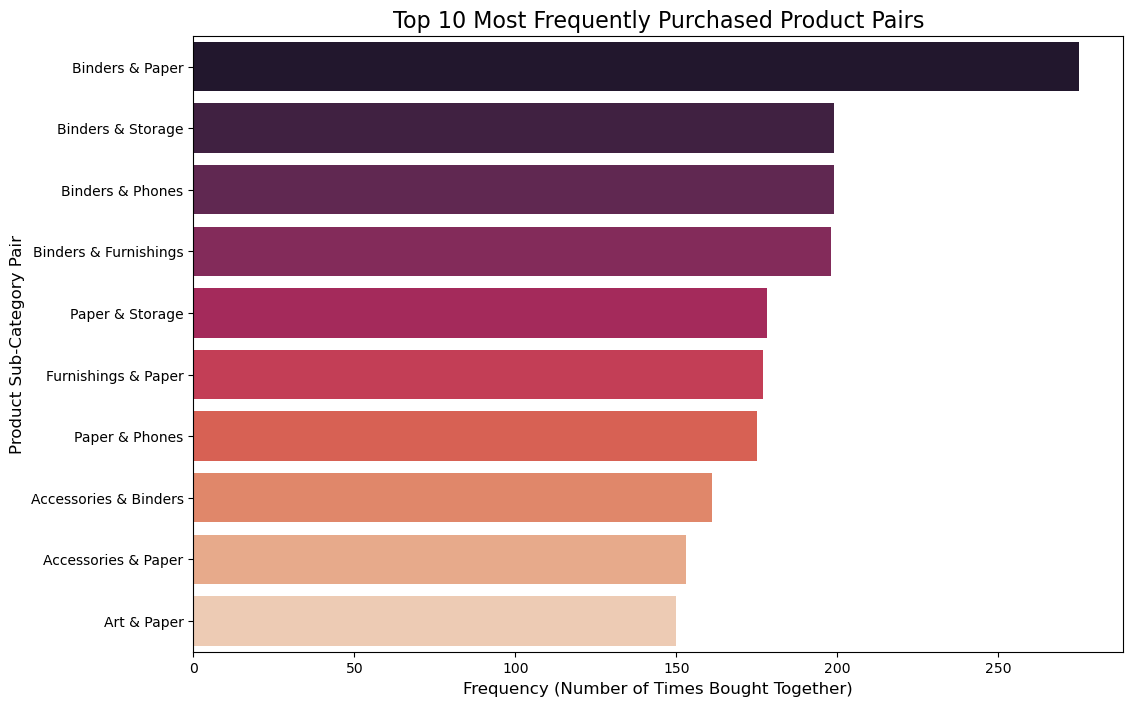

In [225]:
#RQ3: what product combinations are most frequently purchased together, and how can that help in 
#managing different promotions and offers?
#market basket analysis

# Find orders that have more than one item
multi_item_orders = df[df['Order ID'].duplicated(keep=False)]

# Create a new dataframe with pairs of sub-categories bought together
# This is done by merging the table with itself on 'Order ID'
pairs = pd.merge(
    multi_item_orders[['Order ID', 'Sub-Category']],
    multi_item_orders[['Order ID', 'Sub-Category']],
    on='Order ID'
)

# Removing pairs of the same sub-category
pairs = pairs[pairs['Sub-Category_x'] != pairs['Sub-Category_y']]

# Creating a new column for the item pair
pairs['Item_Pair'] = pairs.apply(lambda row: tuple(sorted((row['Sub-Category_x'], row['Sub-Category_y']))), axis=1)
pairs = pairs.drop_duplicates(subset=['Order ID', 'Item_Pair'])

# Counting the frequency / number of  of each pair
pair_counts = pairs['Item_Pair'].value_counts().reset_index()
pair_counts.columns = ['Item_Pair', 'Frequency']

# Selecting the top 10 most frequent pairs
top_10_pairs = pair_counts.head(10)
top_10_pairs['Item_Pair'] = top_10_pairs['Item_Pair'].apply(lambda x: f"{x[0]} & {x[1]}")

plt.figure(figsize=(12, 8))
sns.barplot(x='Frequency', y='Item_Pair', data=top_10_pairs, orient='h', palette='rocket') 
plt.title('Top 10 Most Frequently Purchased Product Pairs', fontsize=16)
plt.xlabel('Frequency (Number of Times Bought Together)', fontsize=12)
plt.ylabel('Product Sub-Category Pair', fontsize=12)
plt.savefig('top_product_pairs.png', dpi=300)
plt.show()

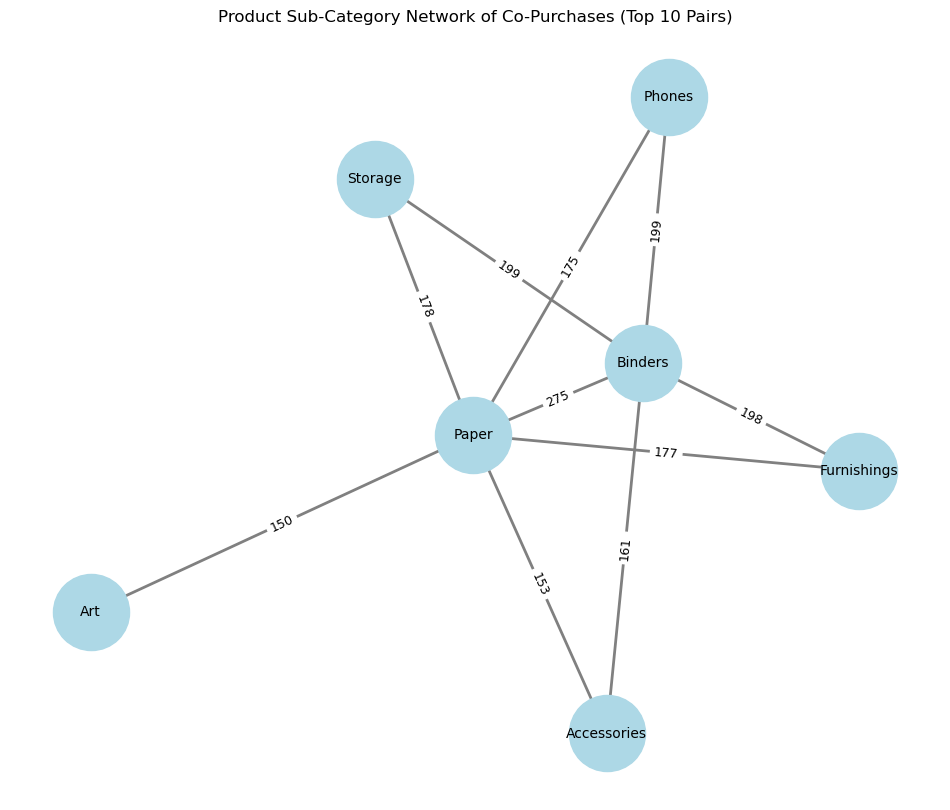

In [237]:
#code reference: claude and youtube
import networkx as nx
import matplotlib.pyplot as plt

# Create a graph object
G = nx.Graph()

# Add edges with weight (top 15 for readability)
for index, row in pair_counts.head(10).iterrows():
    sub1, sub2 = row['Item_Pair']
    G.add_edge(sub1, sub2, weight=row['Frequency'])

# Set layout and draw
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=0.5)

# Draw the graph
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=3000)
nx.draw_networkx_edges(G, pos, width=2, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=10, font_family='sans-serif')

# Draw edge weights (i.e., frequency)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

plt.title("Product Sub-Category Network of Co-Purchases (Top 10 Pairs)")
plt.axis('off')
plt.savefig('product_network.png', dpi=300)
plt.show()

The above bar chart and the network diagram both shows similar co-purchases. Binders appears in the top most sold items with storage and papers. the company should use this information to make various offers. 